### Required Codio Assignment 22.1: Basic Neural Net for Image Data

**Expected Time = 60 minutes**

**Total Points = 30**

This activity focuses on using a basic neural net architecture to predict handwritten digit labels.  Using the basic architecture you will also explore data augmentation using simple transformations of the images to create new data for the network.

#### Index

- [Problem 1](#-Problem-1)
- [Problem 2](#-Problem-2)
- [Problem 3](#-Problem-3)


Run the code cell below to import the necessary libraries.

In [1]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '1'
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist

### The Dataset

You will be using the `mnist` dataset which is included in the `datasets` module of the `keras` library. This dataset contains observations that are 28 x 28 pixel images of handwritten digits.  The labels correspond to the actual digit, forming a 10 category classification problem for you.  Below, the data is loaded and reshaped in anticipation of the neural network architecture.

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)
Y_train = to_categorical(y_train)
Y_test = to_categorical(y_test)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


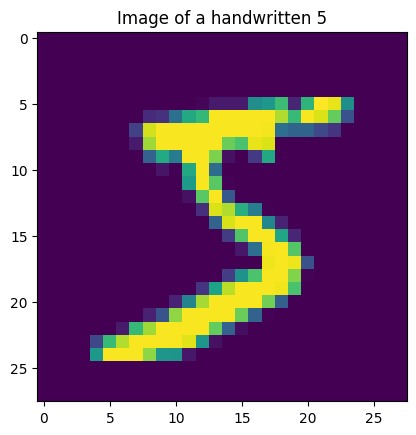

In [3]:
plt.imshow(X_train[0])
plt.title(f'Image of a handwritten {y_train[0]}');

[Back to top](#-Index)

### Problem 1

#### Using a Convolutional Architecture

**10 Points**

Below, use the TensorFlow function `Sequential()` to build a convolutional neural network using the following functions and configurations:

- Use `Flatten` to flatten the images
- Use a single `Dense` hidden layer with 60 nodes and a `relu` activation
- Use a single `Dense` hidden layer with 10 nodes and a `softmax` activiation.

Assign this network to the variable `model`.

Compile `model` using `categorical_crossentropy` as your `loss` and  `accuracy` as your `metric`.

Fit your model to the training data `X_train` and ` Y_train` including `X_test, Y_test` as your validation data. In this step, set the variable `verbose` equal to `0` and the number of `epochs` equal to 2.

Assign the fit model to the `history` variable below.

NOTE: This question is computationally expensive, so please be patient with the processing. It may take a few minutes based on your computing power.

In [4]:
### GRADED
tf.random.set_seed(42)
model = ''
history = ''
# YOUR CODE HERE
model = keras.Sequential([
    layers.Flatten(),
    layers.Dense(60, activation='relu'),
    layers.Dense(10,activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy', metrics =["accuracy"])
print("Fitting a CNN using basic sequential Dense NN")
history= model.fit(X_train, y_train, validation_data=(X_test, y_test), verbose=1, epochs=2)

### ANSWER CHECK
print(history.history['accuracy'][-1])
print(history.history['val_accuracy'][-1])

Fitting a CNN using basic sequential Dense NN
Epoch 1/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8212 - loss: 1.9662 - val_accuracy: 0.8840 - val_loss: 0.7695
Epoch 2/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9052 - loss: 0.6004 - val_accuracy: 0.9212 - val_loss: 0.6066
0.9051666855812073
0.9211999773979187


In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (32, 784)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 60)               │        47,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 10)               │           610 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,422 (372.75 KB)

 Trainable params: 47,710 (186.37 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 47,712 (186.38 KB)

[Back to top](#-Index)

### Problem 2

#### Data Augmentation

**10 Points**

One way to attempt a model improvement is to create new inputs to the network based on transformed versions of the original data.  


In the code cell below, use the `ImageDataGenerator` function from `keras` with the arguments `horizontal_flip` and `vertical_flip` both equal to `True` to create a new version of the train and test data that performs both a horizontal and vertical flip of the images. Assign this new object to the variable `gen` below.  

Perform the horizontal and vertical flips on the training sets by using the `.flow` method on `gen` with arguments `X_train` and `y_train`. Assign this new object to the variable `train_gen`.

Perform the horizontal and vertical flips on the testing sets by using the `.flow` method on `gen` with arguments `X_test` and `y_test`. Assign this new object to the variable `test_gen`.

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

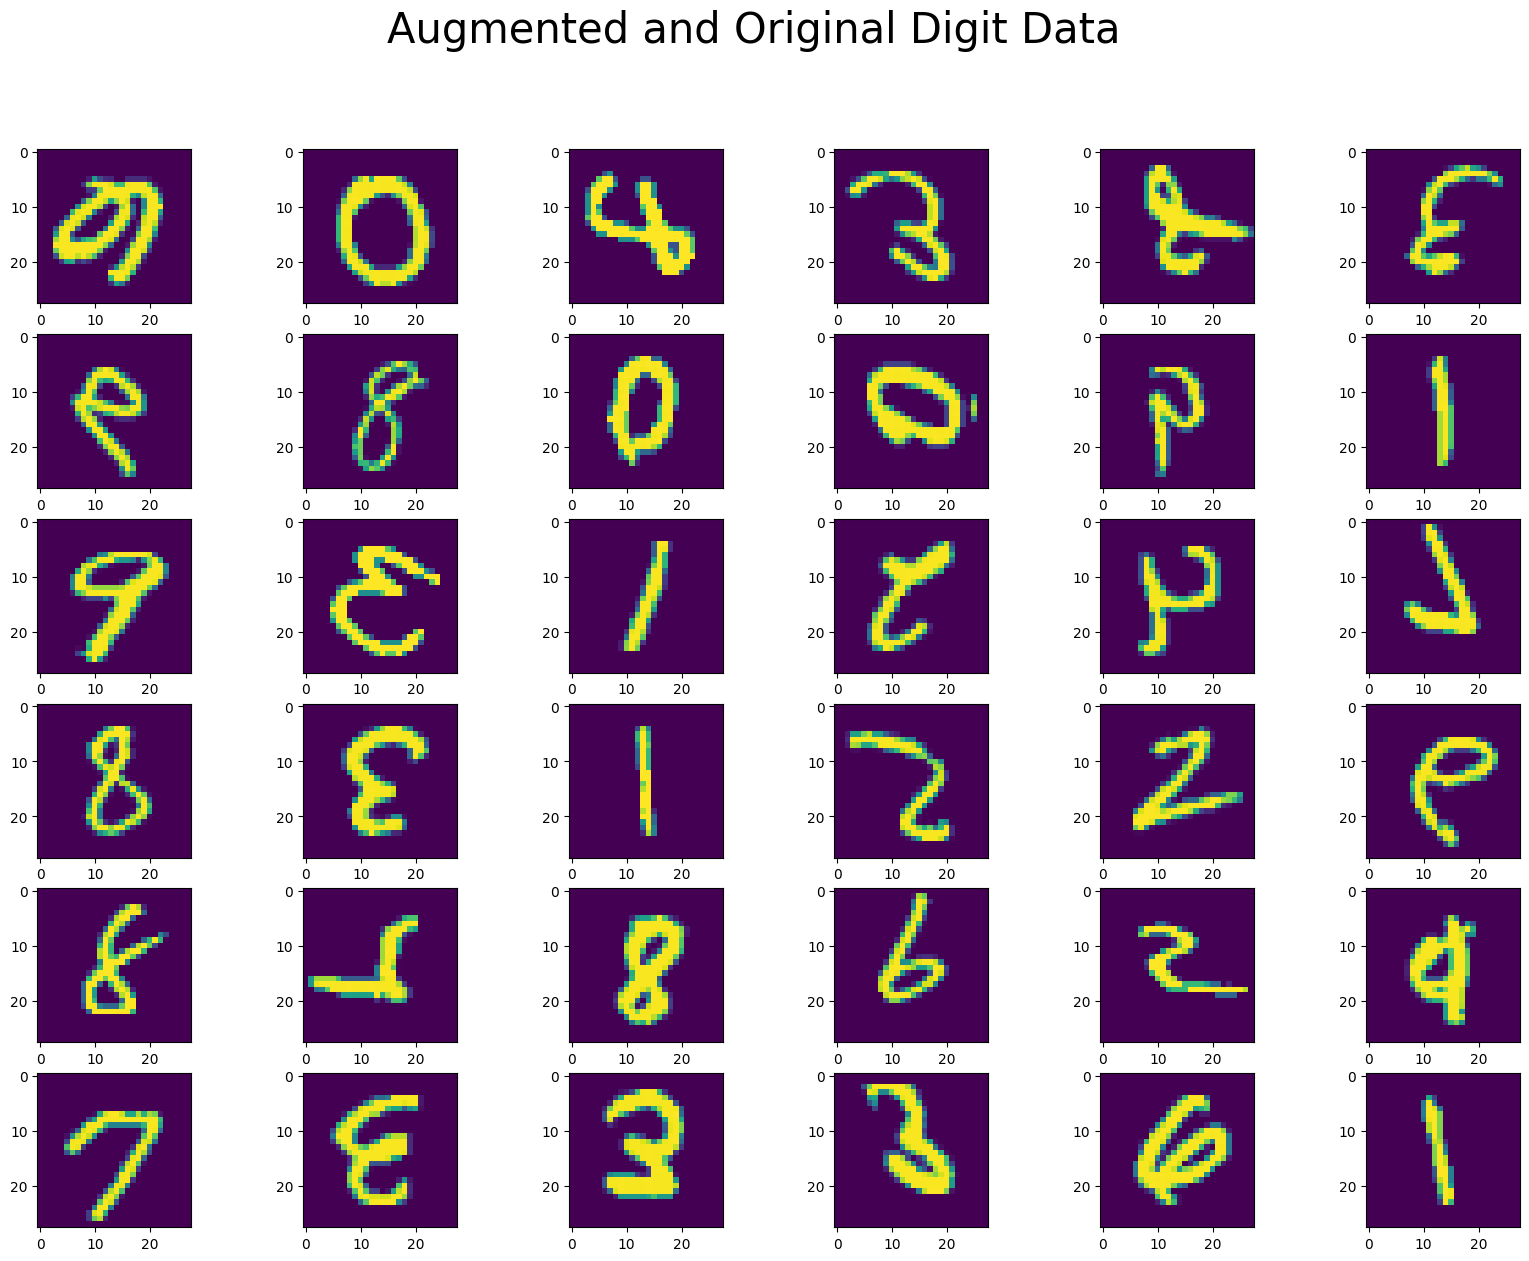

In [10]:
### GRADED
tf.random.set_seed(42)
gen = ''
train_gen = ''
test_gen = ''
# YOUR CODE HERE
gen=ImageDataGenerator(horizontal_flip=True, vertical_flip=True)# create different transformations of the input image by rotating horizontally and vertically both
train_gen=gen.flow(X_train, y_train)
test_gen = gen.flow(X_test, y_test)

### ANSWER CHECK
#UNCOMMENT TO VISUALIZE
fig, ax = plt.subplots(6, 6, figsize = (20, 14))
for i in range(6):
    for j in range(6):
        pic = next(train_gen)
        ax[i, j].imshow(pic[0][0].reshape(28, 28))
plt.suptitle("Augmented and Original Digit Data", fontsize = 30);

[Back to top](#-Index)

### Problem 3

#### Training a model on the augmented data

**10 Points**

Now, your aim is to compare the performance of the convolutional architecture on the augmented version of the data.  You can replace `X_train` and `X_test` in your model fitting with `train_gen` and `test_gen`.  

Create a new model, `aug_model`, with the identical architecture to the first network in **Problem 1** and compile it using the same settings as in **Problem 1**.

This time, fit your model to the data `train_gen` defined in **Problem 2** and use `test_gen` as `validation_data`. In this step, set the variable `verbose` equal to `0` and the number of `epochs` equal to 2.

Assign the fit model to the `augmented_history` variable below.

NOTE: This question is computationally expensive, so please be patient with the processing. It may take a few minutes based on your computing power.


In [14]:
### GRADED
tf.random.set_seed(42)
aug_model = ''
augmented_history = ''
# YOUR CODE HERE
aug_model = keras.Sequential([
    layers.Flatten(),
    layers.Dense(60, activation='relu'),# hidden layer
    layers.Dense(10, activation='softmax') # for the 10 digits
])
aug_model.compile(loss= 'sparse_categorical_crossentropy', metrics = ['accuracy'])
augment_history=aug_model.fit(train_gen,epochs=2, verbose=1 , validation_data= (test_gen))

Epoch 1/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.4306 - loss: 2.8342 - val_accuracy: 0.5171 - val_loss: 1.4893
Epoch 2/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.5475 - loss: 1.4328 - val_accuracy: 0.5633 - val_loss: 1.3832


In [15]:
### ANSWER CHECK
### ANSWER CHECK
print(augment_history.history['accuracy'][-1])
print(augment_history.history['val_accuracy'][-1])

0.5475333333015442
0.5633000135421753


Note the performance difference and think about why it either improved or declined after using the augmented data.